In [1]:
from google.colab import files
uploaded = files.upload()

Saving AirQualityUCI.csv to AirQualityUCI.csv


In [2]:
#step 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import warnings

from scipy.stats import ttest_rel
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.arima.model import ARIMA

from sklearn.linear_model import LinearRegression, LassoCV, HuberRegressor, RANSACRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [3]:
#Step 2

# 1. Drop extra unnamed/empty columns at the end
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# 2. Drop rows that are completely empty
df = df.dropna(how='all')

# 3. Check the actual format of the Date/Time columns (initial inspection)
print(df['Date'].head())
print(df['Time'].head())

# 4. Mark -200 as actual missing value (NaN)
df.replace(-200, np.nan, inplace=True)

# 5. Check missing % per column
print("\nMissing % per column:\n", df.isna().mean() * 100)

# 6. Drop NMHC(GT) if it has mostly missing values
if 'NMHC(GT)' in df.columns:
    df.drop(columns=['NMHC(GT)'], inplace=True)

# 7. Combine Date + Time into a Datetime column
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H.%M.%S'
)

# 8. Drop the old Date and Time columns
df.drop(columns=['Date', 'Time'], inplace=True)

# 9. Set Datetime as index and sort by time
df.set_index('Datetime', inplace=True)
df.sort_index(inplace=True)

print("\nFinal shape:", df.shape)
df.head()

0    10/03/2004
1    10/03/2004
2    10/03/2004
3    10/03/2004
4    10/03/2004
Name: Date, dtype: object
0    18.00.00
1    19.00.00
2    20.00.00
3    21.00.00
4    22.00.00
Name: Time, dtype: object

Missing % per column:
 Date              0.000000
Time              0.000000
CO(GT)           17.986534
PT08.S1(CO)       3.911510
NMHC(GT)         90.231912
C6H6(GT)          3.911510
PT08.S2(NMHC)     3.911510
NOx(GT)          17.516298
PT08.S3(NOx)      3.911510
NO2(GT)          17.548360
PT08.S4(NO2)      3.911510
PT08.S5(O3)       3.911510
T                 3.911510
RH                3.911510
AH                3.911510
dtype: float64

Final shape: (9357, 12)


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [4]:
#Step 3

# 1. Check missing % per column after cleaning
missing_pct = df.isna().mean() * 100
print("Missing % per column:\n", missing_pct.sort_values(ascending=False))

# 2. Separate out columns with high missing values (30%+)
high_missing_cols = missing_pct[missing_pct > 30].index.tolist()
print("\nColumns with high missing values:", high_missing_cols)

# 3. Fill columns with low missing values using time-based interpolation
df.interpolate(method='linear', limit_direction='both', inplace=True)

# 4. If any NaN remains after interpolation (at start/end), drop those rows
df.dropna(inplace=True)

# 5. Final confirmation that no NaN remains
print("\nTotal missing values (after cleaning):", df.isna().sum().sum())
print("Final shape:", df.shape)

df.head()

Missing % per column:
 CO(GT)           17.986534
NO2(GT)          17.548360
NOx(GT)          17.516298
PT08.S1(CO)       3.911510
PT08.S2(NMHC)     3.911510
C6H6(GT)          3.911510
PT08.S3(NOx)      3.911510
PT08.S4(NO2)      3.911510
PT08.S5(O3)       3.911510
T                 3.911510
RH                3.911510
AH                3.911510
dtype: float64

Columns with high missing values: []

Total missing values (after cleaning): 0
Final shape: (9357, 12)


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [5]:
#Step 3.5 : Outlier Detection and Handling (IQR method)
#We will check for outliers in the target CO(GT) and sensor features.


# Only take the numeric features, including the target.
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Identify outliers using the IQR method.
outlier_mask = pd.Series(False, index=df.index)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # We are taking the OR of the outliers across all columns.
    outlier_mask = outlier_mask | ((df[col] < lower_bound) | (df[col] > upper_bound))

print(f"Total outliers found: {outlier_mask.sum()}")

# Convert the outliers to NaN and perform interpolation (or drop them).
df.loc[outlier_mask, numeric_cols] = np.nan

# Time-based interpolation.
df.interpolate(method='linear', limit_direction='both', inplace=True)

# Drop any remaining NaN values.
df.dropna(inplace=True)

print("Shape after outlier handling:", df.shape)

Total outliers found: 943
Shape after outlier handling: (9357, 12)


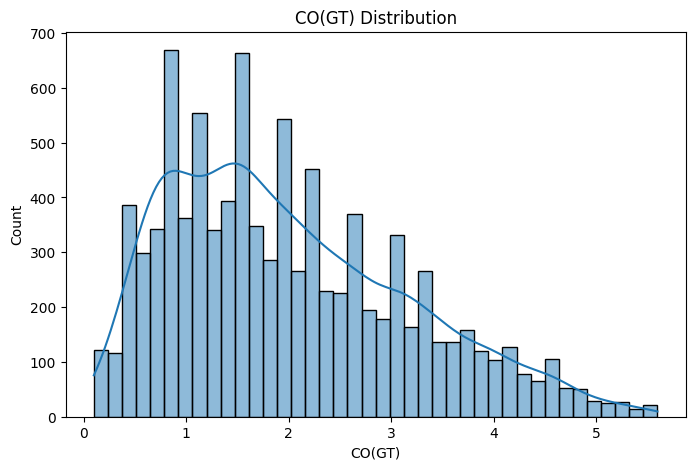

In [6]:
#Step 4
#১.Target Variable এর Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['CO(GT)'], bins=40, kde=True)
plt.title('CO(GT) Distribution')
plt.xlabel('CO(GT)')
plt.show()


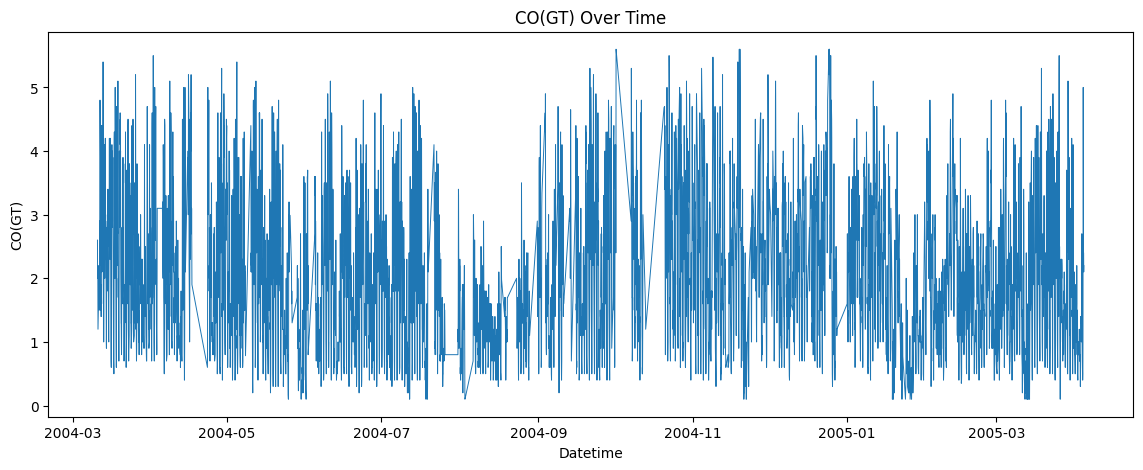

In [7]:
#Step 4
#2. Time-Series Line Plot (how the pollutant fluctuates over time)
plt.figure(figsize=(14,5))
plt.plot(df.index, df['CO(GT)'], linewidth=0.7)
plt.title('CO(GT) Over Time')
plt.xlabel('Datetime')
plt.ylabel('CO(GT)')
plt.show()

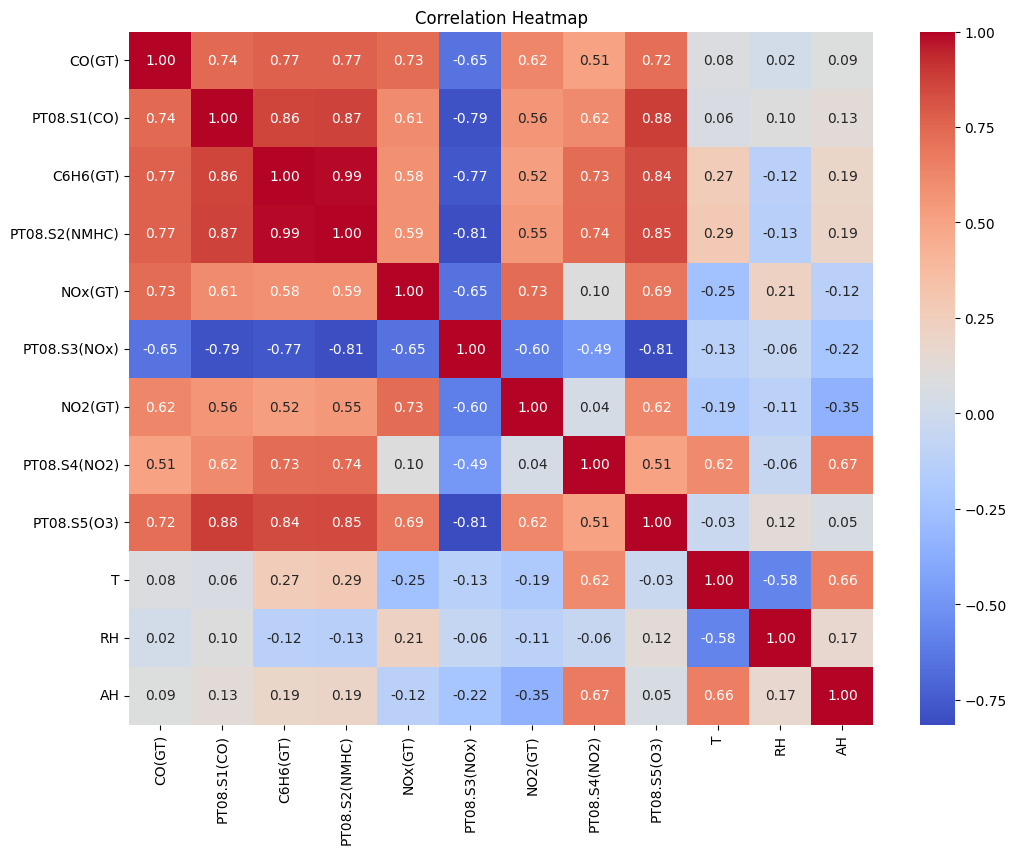

In [8]:
#Step 4
#৩.Correlation Heatmap
plt.figure(figsize=(12,9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


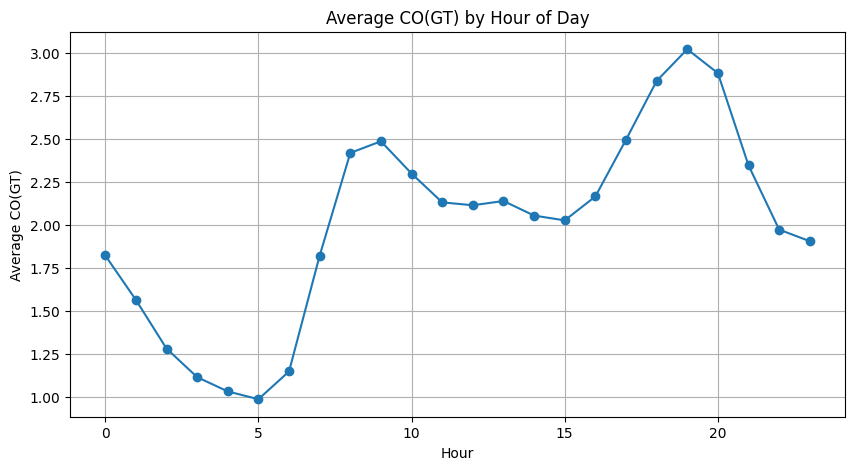

In [9]:
#Step 4
#4. Average CO Level by Hour-of-Day (Diurnal Pattern)
df['hour'] = df.index.hour

plt.figure(figsize=(10,5))
df.groupby('hour')['CO(GT)'].mean().plot(kind='line', marker='o')
plt.title('Average CO(GT) by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average CO(GT)')
plt.grid(True)
plt.show()

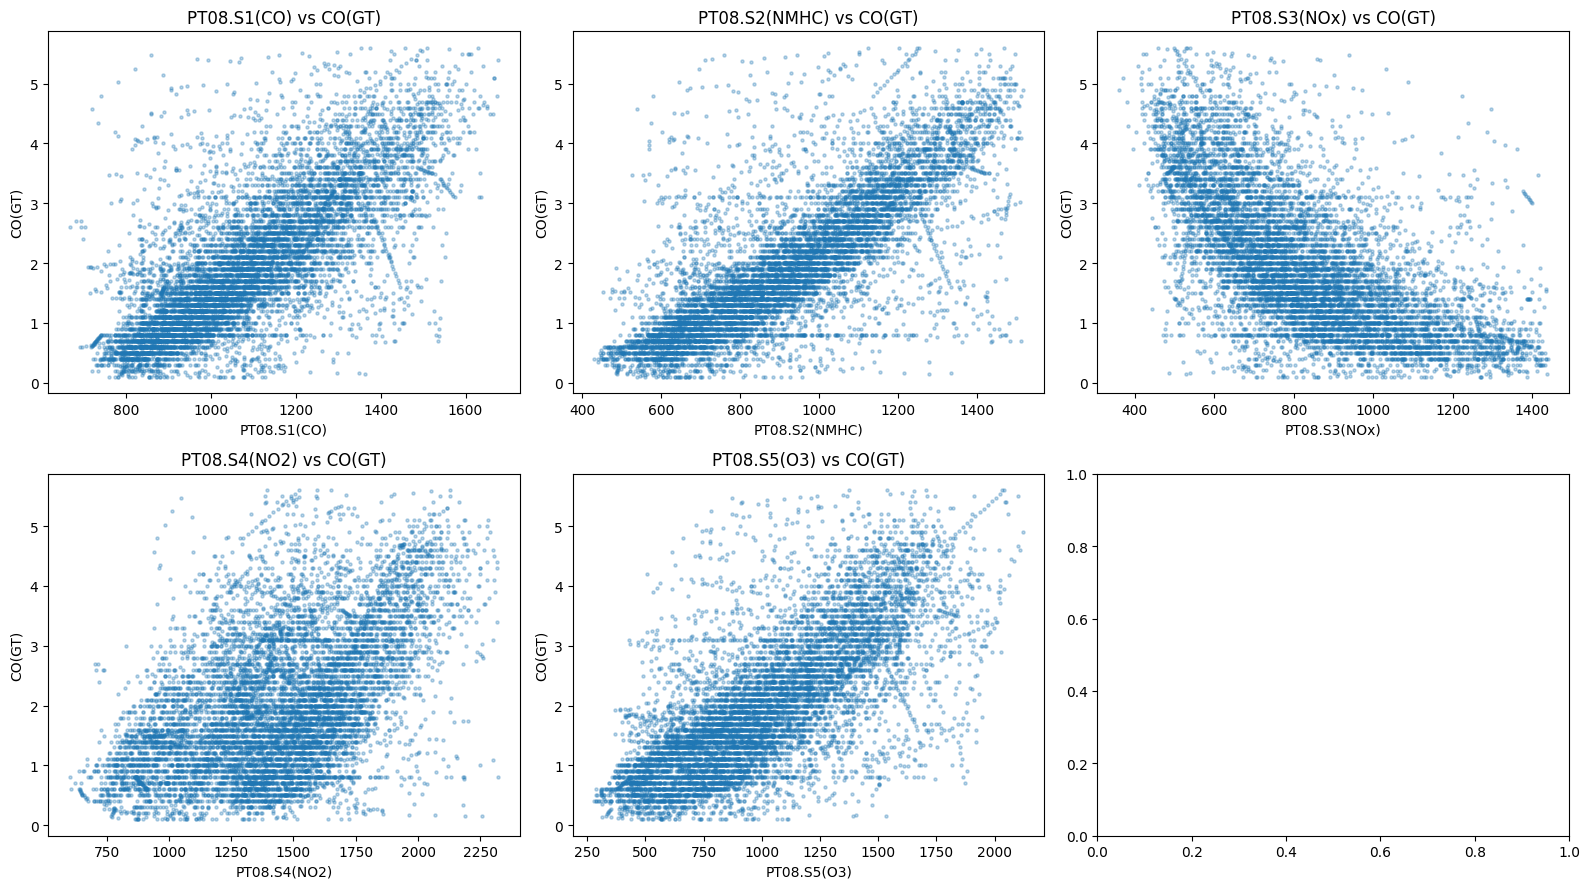

In [10]:
#Step 4
#5. Sensor Feature vs Target — Scatter Plot
sensor_cols = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']

fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    axes[i].scatter(df[col], df['CO(GT)'], alpha=0.3, s=5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('CO(GT)')
    axes[i].set_title(f'{col} vs CO(GT)')

plt.tight_layout()
plt.show()

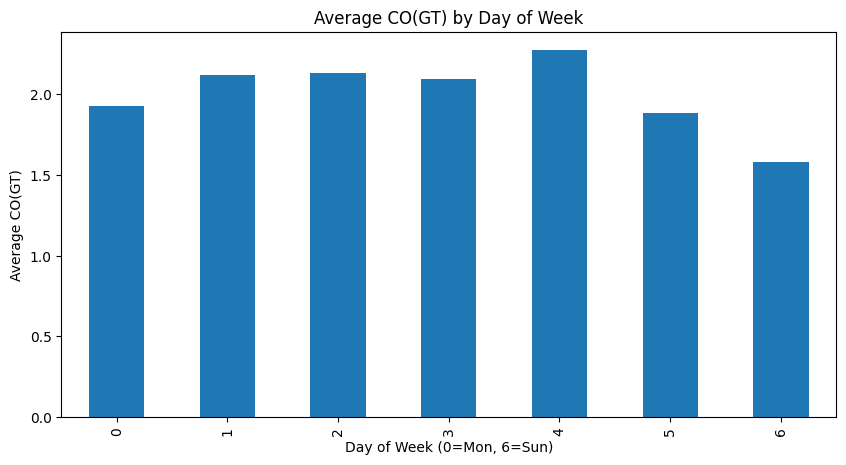

In [11]:
#Step 4
#Weekday-wise Pattern
df['day_of_week'] = df.index.dayofweek  # 0=Monday, 6=Sunday

plt.figure(figsize=(10,5))
df.groupby('day_of_week')['CO(GT)'].mean().plot(kind='bar')
plt.title('Average CO(GT) by Day of Week')
plt.xlabel('Day of Week (0=Mon, 6=Sun)')
plt.ylabel('Average CO(GT)')
plt.show()

In [12]:

# STEP 5 : Feature Engineering


# 1. Month Feature
df['month'] = df.index.month

# 2. Cyclical Encoding of Hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# 3. Lag Feature (Previous Hour CO)
df['CO_lag1'] = df['CO(GT)'].shift(1)

# 4. Rolling Mean (Last 3 Hours Average)
df['CO_roll3'] = df['CO(GT)'].rolling(window=3).mean()

# 5. Remove NaN created by lag & rolling
df.dropna(inplace=True)

# 6. Check the new dataset
print("Shape after Feature Engineering:", df.shape)

new_features = [
    'hour', 'day_of_week', 'month',
    'hour_sin', 'hour_cos',
    'CO_lag1', 'CO_roll3'
]

print("\nNew Features Added:")
print(new_features)

df[new_features + ['CO(GT)']].head()

Shape after Feature Engineering: (9355, 19)

New Features Added:
['hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 'CO_lag1', 'CO_roll3']


,hour,day_of_week,month,hour_sin,hour_cos,CO_lag1,CO_roll3,CO(GT)
Datetime,,,,,,,,
2004-03-10 20:00:00,20,2,3,-0.866025,0.500000,2.0,2.266667,2.200000
2004-03-10 21:00:00,21,2,3,-0.707107,0.707107,2.2,2.133333,2.200000
2004-03-10 22:00:00,22,2,3,-0.500000,0.866025,2.2,2.000000,1.600000
2004-03-10 23:00:00,23,2,3,-0.258819,0.965926,1.6,1.666667,1.200000
2004-03-11 00:00:00,0,3,3,0.000000,1.000000,1.2,1.362963,1.288889


In [13]:
#Step 6
#1
# Check the correlation of each feature with the target
corr_with_target = df.corr(numeric_only=True)['CO(GT)'].sort_values(ascending=False)
print("Correlation with CO(GT):\n", corr_with_target)

Correlation with CO(GT):
 CO(GT)           1.000000
CO_roll3         0.920348
CO_lag1          0.880832
PT08.S2(NMHC)    0.770279
C6H6(GT)         0.769979
PT08.S1(CO)      0.741281
NOx(GT)          0.726611
PT08.S5(O3)      0.719010
NO2(GT)          0.624514
PT08.S4(NO2)     0.505333
hour             0.329090
month            0.145238
AH               0.091173
T                0.075748
RH               0.021634
day_of_week     -0.084010
hour_cos        -0.160917
hour_sin        -0.331752
PT08.S3(NOx)    -0.646590
Name: CO(GT), dtype: float64


In [14]:
#Step 6
#2

# Take all numeric features except the target
feature_cols = [col for col in df.select_dtypes(include='number').columns if col != 'CO(GT)']
X = df[feature_cols].dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data.sort_values('VIF', ascending=False))

          feature         VIF
2   PT08.S2(NMHC)  649.236172
6    PT08.S4(NO2)  343.558702
0     PT08.S1(CO)  266.205517
17       CO_roll3  127.126340
16        CO_lag1   99.962276
1        C6H6(GT)   92.140577
10             AH   91.037041
7     PT08.S5(O3)   80.832023
8               T   79.705886
9              RH   79.196878
4    PT08.S3(NOx)   44.262972
5         NO2(GT)   32.710024
3         NOx(GT)   18.986916
11           hour   10.033945
13          month    9.710810
12    day_of_week    3.542038
14       hour_sin    3.457267
15       hour_cos    1.562281


In [15]:
#Step 6
#3

X = df[feature_cols]
y = df['CO(GT)']

# Scaling is necessary because LASSO is scale-sensitive
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y)

lasso_coef = pd.Series(lasso.coef_, index=feature_cols).sort_values(key=abs, ascending=False)
print("LASSO Coefficients (by importance):\n", lasso_coef)

# Features with coefficient close to 0 are considered dropped by LASSO
selected_features = lasso_coef[lasso_coef.abs() > 1e-4].index.tolist()
print("\nFeatures selected by LASSO:\n", selected_features)

LASSO Coefficients (by importance):
 CO_roll3         1.084746
PT08.S4(NO2)     0.399590
C6H6(GT)         0.344651
CO_lag1         -0.332440
PT08.S2(NMHC)   -0.325817
NOx(GT)          0.293281
PT08.S5(O3)     -0.223078
T               -0.159006
RH              -0.101938
NO2(GT)          0.076556
AH              -0.073971
PT08.S1(CO)      0.073603
PT08.S3(NOx)    -0.046991
hour            -0.041709
day_of_week      0.026726
month            0.025663
hour_cos        -0.007341
hour_sin         0.006762
dtype: float64

Features selected by LASSO:
 ['CO_roll3', 'PT08.S4(NO2)', 'C6H6(GT)', 'CO_lag1', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S5(O3)', 'T', 'RH', 'NO2(GT)', 'AH', 'PT08.S1(CO)', 'PT08.S3(NOx)', 'hour', 'day_of_week', 'month', 'hour_cos', 'hour_sin']


In [16]:
#Step 6
#4
# Based on the three analyses above (correlation, VIF, LASSO), build the list of features to keep
final_features = selected_features  # or adjust based on your own judgment

print("Final Feature Set:\n", final_features)

X_final = df[final_features]
y_final = df['CO(GT)']

print("\nX shape:", X_final.shape)
print("y shape:", y_final.shape)

Final Feature Set:
 ['CO_roll3', 'PT08.S4(NO2)', 'C6H6(GT)', 'CO_lag1', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S5(O3)', 'T', 'RH', 'NO2(GT)', 'AH', 'PT08.S1(CO)', 'PT08.S3(NOx)', 'hour', 'day_of_week', 'month', 'hour_cos', 'hour_sin']

X shape: (9355, 18)
y shape: (9355,)


In [17]:
#Step 7
# Chronological split — not a random split, since this is time-series data
split_idx = int(len(df) * 0.75)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df[final_features]
y_train = train_df['CO(GT)']

X_test = test_df[final_features]
y_test = test_df['CO(GT)']

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nTrain period:", train_df.index.min(), "→", train_df.index.max())
print("Test period:", test_df.index.min(), "→", test_df.index.max())


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Store the feature names
feature_names = X_train.columns
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

Train shape: (7016, 18) (7016,)
Test shape: (2339, 18) (2339,)

Train period: 2004-03-10 20:00:00 → 2004-12-28 03:00:00
Test period: 2004-12-28 04:00:00 → 2005-04-04 14:00:00


In [18]:

# Assume that `X_train_scaled` and `y_train` have already been defined.
tscv = TimeSeriesSplit(n_splits=5)
rmse_list = []
mae_list = []

for train_idx, val_idx in tscv.split(X_train_scaled):
    # If `X_train_scaled` is a DataFrame, use `.iloc`.
    X_tr = X_train_scaled.iloc[train_idx]
    X_val = X_train_scaled.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model = LinearRegression()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    rmse_list.append(np.sqrt(mean_squared_error(y_val, y_pred)))
    mae_list.append(mean_absolute_error(y_val, y_pred))

print(f"TimeSeries CV RMSE: mean={np.mean(rmse_list):.4f} (+/- {np.std(rmse_list):.4f})")
print(f"TimeSeries CV MAE:  mean={np.mean(mae_list):.4f} (+/- {np.std(mae_list):.4f})")

TimeSeries CV RMSE: mean=0.4140 (+/- 0.0769)
TimeSeries CV MAE:  mean=0.3022 (+/- 0.0625)


===== OLS Baseline Model Results =====
Train RMSE: 0.3268 | Train MAE: 0.2460 | Train R²: 0.9251
Test  RMSE: 0.3152 | Test  MAE: 0.2358 | Test  R²: 0.9088
Adjusted R² (Test): 0.9081

Model Coefficients:
 CO_roll3         1.022654
AH              -0.378364
CO_lag1         -0.321651
C6H6(GT)         0.079605
month            0.022939
day_of_week      0.016900
T               -0.014919
hour_sin         0.011124
hour_cos        -0.009625
RH              -0.005498
hour            -0.004876
PT08.S2(NMHC)   -0.002699
NO2(GT)          0.002526
NOx(GT)          0.001890
PT08.S4(NO2)     0.001674
PT08.S5(O3)     -0.000696
PT08.S1(CO)      0.000572
PT08.S3(NOx)    -0.000435
dtype: float64


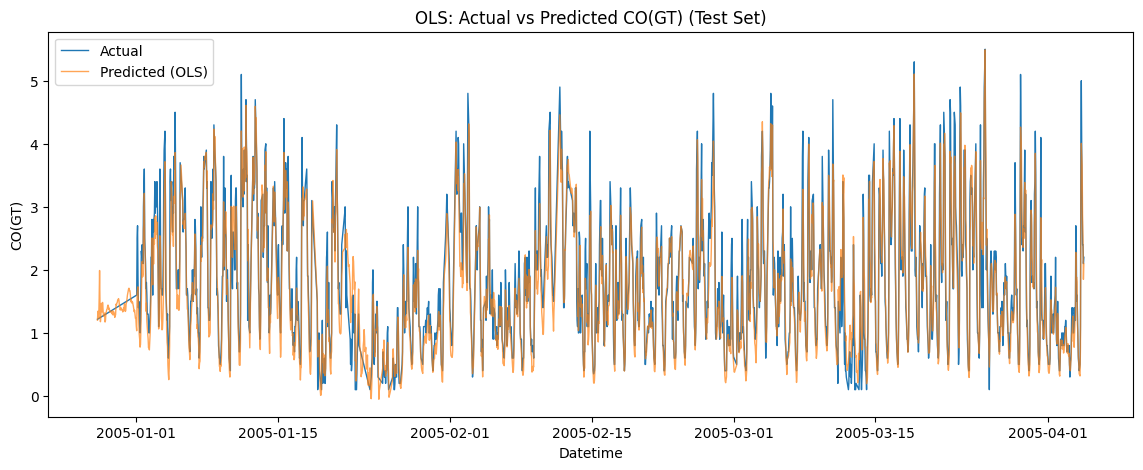

In [19]:
#Step 8


# 1. Build and train the model
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

# 2. Prediction on train and test sets
y_train_pred = ols_model.predict(X_train)
y_test_pred = ols_model.predict(X_test)

# 3. Evaluation Metrics — Train
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# 4. Evaluation Metrics — Test
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# 5. Adjusted R² (for the Test set)
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2_test = 1 - (1 - test_r2) * (n - 1) / (n - p - 1)

print("===== OLS Baseline Model Results =====")
print(f"Train RMSE: {train_rmse:.4f} | Train MAE: {train_mae:.4f} | Train R²: {train_r2:.4f}")
print(f"Test  RMSE: {test_rmse:.4f} | Test  MAE: {test_mae:.4f} | Test  R²: {test_r2:.4f}")
print(f"Adjusted R² (Test): {adj_r2_test:.4f}")

# 6. Check coefficients (how much each feature influences the prediction)
coef_df = pd.Series(ols_model.coef_, index=final_features).sort_values(key=abs, ascending=False)
print("\nModel Coefficients:\n", coef_df)

# 7. Actual vs Predicted plot (on the Test set)
plt.figure(figsize=(14,5))
plt.plot(test_df.index, y_test, label='Actual', linewidth=1)
plt.plot(test_df.index, y_test_pred, label='Predicted (OLS)', linewidth=1, alpha=0.7)
plt.title('OLS: Actual vs Predicted CO(GT) (Test Set)')
plt.xlabel('Datetime')
plt.ylabel('CO(GT)')
plt.legend()
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


===== Huber Regressor Results =====
Train RMSE: 0.5454 | Train MAE: 0.3920 | Train R²: 0.7914
Test  RMSE: 0.8619 | Test  MAE: 0.6807 | Test  R²: 0.3185

===== RANSAC Regressor Results =====
Train RMSE: 0.3418 | Train MAE: 0.2543 | Train R²: 0.9181
Test  RMSE: 0.3513 | Test  MAE: 0.2678 | Test  R²: 0.8868

===== Model Comparison Table =====
    Model  Test RMSE  Test MAE   Test R2
0     OLS   0.315221  0.235757  0.908845
1   Huber   0.861877  0.680749  0.318539
2  RANSAC   0.351324  0.267796  0.886769


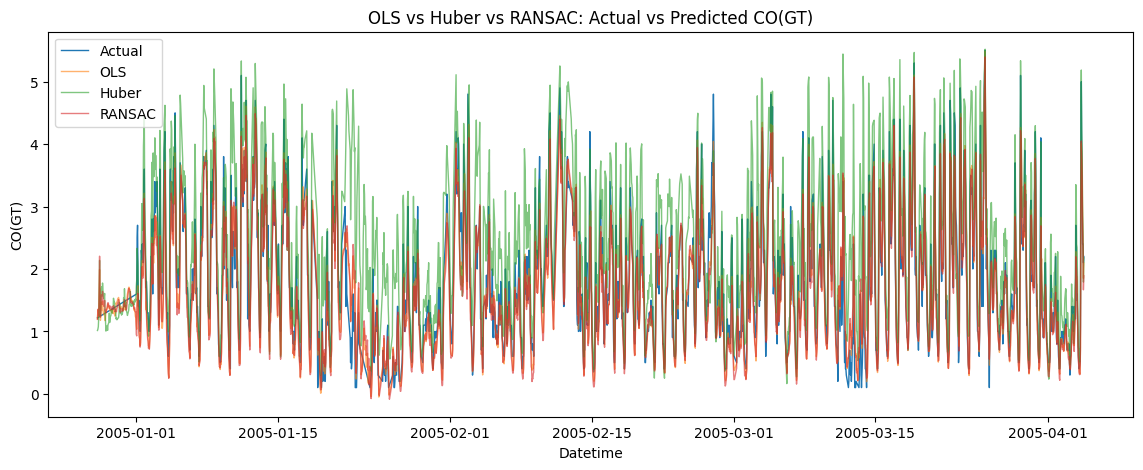

In [20]:
#Step 9


# ===== Huber Regressor =====
huber_model = HuberRegressor()
huber_model.fit(X_train, y_train)

y_train_pred_huber = huber_model.predict(X_train)
y_test_pred_huber = huber_model.predict(X_test)

huber_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_huber))
huber_train_mae = mean_absolute_error(y_train, y_train_pred_huber)
huber_train_r2 = r2_score(y_train, y_train_pred_huber)

huber_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_huber))
huber_test_mae = mean_absolute_error(y_test, y_test_pred_huber)
huber_test_r2 = r2_score(y_test, y_test_pred_huber)

print("===== Huber Regressor Results =====")
print(f"Train RMSE: {huber_train_rmse:.4f} | Train MAE: {huber_train_mae:.4f} | Train R²: {huber_train_r2:.4f}")
print(f"Test  RMSE: {huber_test_rmse:.4f} | Test  MAE: {huber_test_mae:.4f} | Test  R²: {huber_test_r2:.4f}")

# ===== RANSAC Regressor =====
ransac_model = RANSACRegressor(random_state=42)
ransac_model.fit(X_train, y_train)

y_train_pred_ransac = ransac_model.predict(X_train)
y_test_pred_ransac = ransac_model.predict(X_test)

ransac_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_ransac))
ransac_train_mae = mean_absolute_error(y_train, y_train_pred_ransac)
ransac_train_r2 = r2_score(y_train, y_train_pred_ransac)

ransac_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_ransac))
ransac_test_mae = mean_absolute_error(y_test, y_test_pred_ransac)
ransac_test_r2 = r2_score(y_test, y_test_pred_ransac)

print("\n===== RANSAC Regressor Results =====")
print(f"Train RMSE: {ransac_train_rmse:.4f} | Train MAE: {ransac_train_mae:.4f} | Train R²: {ransac_train_r2:.4f}")
print(f"Test  RMSE: {ransac_test_rmse:.4f} | Test  MAE: {ransac_test_mae:.4f} | Test  R²: {ransac_test_r2:.4f}")

# ===== Comparison Table for three models (OLS vs Huber vs RANSAC) =====
comparison_df = pd.DataFrame({
    'Model': ['OLS', 'Huber', 'RANSAC'],
    'Test RMSE': [test_rmse, huber_test_rmse, ransac_test_rmse],
    'Test MAE': [test_mae, huber_test_mae, ransac_test_mae],
    'Test R2': [test_r2, huber_test_r2, ransac_test_r2]
})

print("\n===== Model Comparison Table =====")
print(comparison_df)

# ===== Actual vs Predicted plot (all three models together) =====
plt.figure(figsize=(14,5))
plt.plot(test_df.index, y_test, label='Actual', linewidth=1)
plt.plot(test_df.index, y_test_pred, label='OLS', linewidth=1, alpha=0.6)
plt.plot(test_df.index, y_test_pred_huber, label='Huber', linewidth=1, alpha=0.6)
plt.plot(test_df.index, y_test_pred_ransac, label='RANSAC', linewidth=1, alpha=0.6)
plt.title('OLS vs Huber vs RANSAC: Actual vs Predicted CO(GT)')
plt.xlabel('Datetime')
plt.ylabel('CO(GT)')
plt.legend()
plt.show()

In [21]:
# ===== Huber Regressor Fix: Convergence Warning Resolution =====
# Original fit produced a ConvergenceWarning (lbfgs failed to converge, max_iter=100 default).
# Fix: (1) scale features since Huber's optimizer is sensitive to feature scale,
#      (2) increase max_iter so lbfgs has room to converge properly.


scaler_huber = StandardScaler()
X_train_scaled_h = scaler_huber.fit_transform(X_train)
X_test_scaled_h = scaler_huber.transform(X_test)

huber_model_fixed = HuberRegressor(max_iter=1000)
huber_model_fixed.fit(X_train_scaled_h, y_train)

y_train_pred_huber_fixed = huber_model_fixed.predict(X_train_scaled_h)
y_test_pred_huber_fixed = huber_model_fixed.predict(X_test_scaled_h)

huber_fixed_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_huber_fixed))
huber_fixed_train_mae = mean_absolute_error(y_train, y_train_pred_huber_fixed)
huber_fixed_train_r2 = r2_score(y_train, y_train_pred_huber_fixed)

huber_fixed_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_huber_fixed))
huber_fixed_test_mae = mean_absolute_error(y_test, y_test_pred_huber_fixed)
huber_fixed_test_r2 = r2_score(y_test, y_test_pred_huber_fixed)

print("===== Huber Regressor (Fixed: scaled + max_iter=1000) =====")
print(f"Train RMSE: {huber_fixed_train_rmse:.4f} | Train MAE: {huber_fixed_train_mae:.4f} | Train R²: {huber_fixed_train_r2:.4f}")
print(f"Test  RMSE: {huber_fixed_test_rmse:.4f} | Test  MAE: {huber_fixed_test_mae:.4f} | Test  R²: {huber_fixed_test_r2:.4f}")

print("\n===== Before vs After Comparison =====")
comparison_huber_fix = pd.DataFrame({
    'Version': ['Original (unscaled, max_iter=100)', 'Fixed (scaled, max_iter=1000)'],
    'Test RMSE': [huber_test_rmse, huber_fixed_test_rmse],
    'Test MAE': [huber_test_mae, huber_fixed_test_mae],
    'Test R2': [huber_test_r2, huber_fixed_test_r2]
})
print(comparison_huber_fix.to_string(index=False))

===== Huber Regressor (Fixed: scaled + max_iter=1000) =====
Train RMSE: 0.3275 | Train MAE: 0.2450 | Train R²: 0.9248
Test  RMSE: 0.3212 | Test  MAE: 0.2426 | Test  R²: 0.9054

===== Before vs After Comparison =====
                          Version  Test RMSE  Test MAE  Test R2
Original (unscaled, max_iter=100)   0.861877  0.680749 0.318539
    Fixed (scaled, max_iter=1000)   0.321189  0.242584 0.905360


In [22]:
# ===== Propagate the FIXED Huber model into all downstream analysis =====
# Table I (paper) specifies the Huber optimizer as LBFGS, max_iter=1000, scaled features
# -- i.e. huber_model_fixed above. Every cell below this point was still referencing the
# original unscaled / unconverged fit from Step 9. Point the shared variable names at the
# fixed model so the comparison table, residual diagnostics, Durbin-Watson test, paired
# t-tests, and plots all use the converged Huber model.
y_train_pred_huber = y_train_pred_huber_fixed
y_test_pred_huber = y_test_pred_huber_fixed
huber_train_rmse = huber_fixed_train_rmse
huber_train_mae = huber_fixed_train_mae
huber_train_r2 = huber_fixed_train_r2
huber_test_rmse = huber_fixed_test_rmse
huber_test_mae = huber_fixed_test_mae
huber_test_r2 = huber_fixed_test_r2


===== Sliding-Window Regression (Window=1 week) =====
RMSE: 1.6407 | MAE: 1.2735 | R²: -1.3632
Best ARIMA order: (2, 0, 2) with AIC: -564.86

===== Hybrid (OLS + ARIMA Residual) =====
RMSE: 0.3153 | MAE: 0.2359 | R²: 0.9088

===== Updated Model Comparison =====
            Model  Test RMSE  Test MAE   Test R2
0             OLS   0.315221  0.235757  0.908845
1           Huber   0.321189  0.242584  0.905360
2          RANSAC   0.351324  0.267796  0.886769
3  Sliding-Window   1.640654  1.273481 -1.363227
4    Hybrid ARIMA   0.315320  0.235857  0.908788


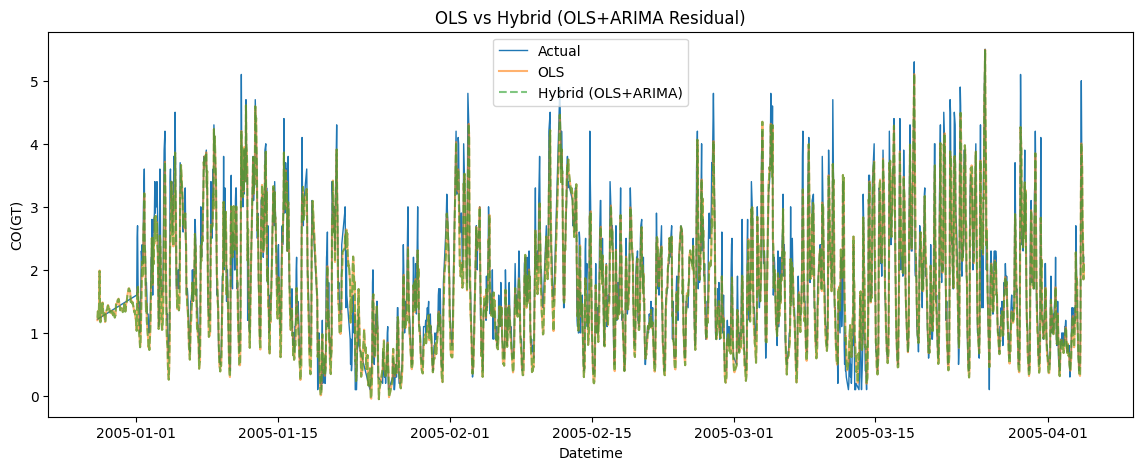

In [23]:
# Step 10 : Drift Handling (Sliding-Window Regression) & Hybrid ARIMA


# 1. Sliding-Window Regression (Recursive)
window_size = 24 * 7
predictions_sw = []
actuals_sw = []

# Sliding window only for the test set.
for i in range(window_size, len(X_test)):
    # Window data
    X_train_win = X_train.iloc[i-window_size:i]
    y_train_win = y_train.iloc[i-window_size:i]
    # Current point
    X_test_win = X_test.iloc[i:i+1]
    y_test_win = y_test.iloc[i]

    model = LinearRegression()
    model.fit(X_train_win, y_train_win)
    pred = model.predict(X_test_win)[0]
    predictions_sw.append(pred)
    actuals_sw.append(y_test_win)

sw_rmse = np.sqrt(mean_squared_error(actuals_sw, predictions_sw))
sw_mae = mean_absolute_error(actuals_sw, predictions_sw)
sw_r2 = r2_score(actuals_sw, predictions_sw)

print("===== Sliding-Window Regression (Window=1 week) =====")
print(f"RMSE: {sw_rmse:.4f} | MAE: {sw_mae:.4f} | R²: {sw_r2:.4f}")

# 2. Hybrid Approach: OLS + ARIMA on Residuals
ols_pred_train = ols_model.predict(X_train)
ols_residuals = y_train - ols_pred_train

# Fit an ARIMA model on the residuals (with automatic order selection).
# Find the best order by minimizing AIC (for simplicity, use `(p,d,q) = (1,0,1)` or `auto_arima`).
warnings.filterwarnings("ignore")

best_aic = np.inf
best_order = None
for p in range(0, 3):
    for d in range(0, 2):
        for q in range(0, 3):
            try:
                model_arima = ARIMA(ols_residuals, order=(p,d,q))
                fitted_arima = model_arima.fit()
                if fitted_arima.aic < best_aic:
                    best_aic = fitted_arima.aic
                    best_order = (p,d,q)
            except:
                continue

print(f"Best ARIMA order: {best_order} with AIC: {best_aic:.2f}")

# Predict the residuals for the test set
model_arima_final = ARIMA(ols_residuals, order=best_order)
fitted_arima_final = model_arima_final.fit()
residual_pred_test = fitted_arima_final.forecast(steps=len(X_test))

# OLS prediction + ARIMA residual prediction.
ols_pred_test = ols_model.predict(X_test)
hybrid_pred = ols_pred_test + residual_pred_test

hybrid_rmse = np.sqrt(mean_squared_error(y_test, hybrid_pred))
hybrid_mae = mean_absolute_error(y_test, hybrid_pred)
hybrid_r2 = r2_score(y_test, hybrid_pred)

print("\n===== Hybrid (OLS + ARIMA Residual) =====")
print(f"RMSE: {hybrid_rmse:.4f} | MAE: {hybrid_mae:.4f} | R²: {hybrid_r2:.4f}")

# 3. Update the comparison table
comparison_df_updated = pd.DataFrame({
    'Model': ['OLS', 'Huber', 'RANSAC', 'Sliding-Window', 'Hybrid ARIMA'],
    'Test RMSE': [test_rmse, huber_test_rmse, ransac_test_rmse, sw_rmse, hybrid_rmse],
    'Test MAE': [test_mae, huber_test_mae, ransac_test_mae, sw_mae, hybrid_mae],
    'Test R2': [test_r2, huber_test_r2, ransac_test_r2, sw_r2, hybrid_r2]
})

print("\n===== Updated Model Comparison =====")
print(comparison_df_updated)

plt.figure(figsize=(14,5))
plt.plot(test_df.index, y_test, label='Actual', linewidth=1)
plt.plot(test_df.index, ols_pred_test, label='OLS', alpha=0.6)
plt.plot(test_df.index, hybrid_pred, label='Hybrid (OLS+ARIMA)', alpha=0.6, linestyle='--')
plt.title('OLS vs Hybrid (OLS+ARIMA Residual)')
plt.xlabel('Datetime')
plt.ylabel('CO(GT)')
plt.legend()
plt.show()

In [24]:
# Step 9.2: Sliding Window (last 7 days)
window = 168
preds, acts = [], []
for i in range(window, len(X_test)):
    Xw = X_train.iloc[i-window:i]
    yw = y_train.iloc[i-window:i]
    m = LinearRegression().fit(Xw, yw)
    preds.append(m.predict(X_test.iloc[i:i+1])[0])
    acts.append(y_test.iloc[i])
print("SW RMSE:", np.sqrt(mean_squared_error(acts, preds)))

SW RMSE: 1.6406542196124467


In [25]:

# ----- Random Forest -----
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rf_train_mae = mean_absolute_error(y_train, y_train_pred_rf)
rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)

print("===== Random Forest Results =====")
print(f"Train RMSE: {rf_train_rmse:.4f} | Train MAE: {rf_train_mae:.4f} | Train R²: {rf_train_r2:.4f}")
print(f"Test  RMSE: {rf_test_rmse:.4f} | Test  MAE: {rf_test_mae:.4f} | Test  R²: {rf_test_r2:.4f}")

# ----- XGBoost -----
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_train_pred_xgb = xgb_model.predict(X_train_scaled)
y_test_pred_xgb = xgb_model.predict(X_test_scaled)

xgb_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
xgb_train_mae = mean_absolute_error(y_train, y_train_pred_xgb)
xgb_train_r2 = r2_score(y_train, y_train_pred_xgb)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
xgb_test_mae = mean_absolute_error(y_test, y_test_pred_xgb)
xgb_test_r2 = r2_score(y_test, y_test_pred_xgb)

print("\n===== XGBoost Results =====")
print(f"Train RMSE: {xgb_train_rmse:.4f} | Train MAE: {xgb_train_mae:.4f} | Train R²: {xgb_train_r2:.4f}")
print(f"Test  RMSE: {xgb_test_rmse:.4f} | Test  MAE: {xgb_test_mae:.4f} | Test  R²: {xgb_test_r2:.4f}")

===== Random Forest Results =====
Train RMSE: 0.0884 | Train MAE: 0.0580 | Train R²: 0.9945
Test  RMSE: 0.3217 | Test  MAE: 0.2324 | Test  R²: 0.9050

===== XGBoost Results =====
Train RMSE: 0.1369 | Train MAE: 0.1011 | Train R²: 0.9869
Test  RMSE: 0.4330 | Test  MAE: 0.3443 | Test  R²: 0.8280


===== Sliding-Window (Recursive) Regression Results =====
Test RMSE: 0.2627 | Test MAE: 0.1879 | Test R²: 0.9367

===== Full Model Comparison Table =====
            Model  Test RMSE  Test MAE   Test R2
0             OLS   0.315221  0.235757  0.908845
1           Huber   0.321189  0.242584  0.905360
2          RANSAC   0.351324  0.267796  0.886769
3  Sliding-Window   0.262693  0.187853  0.936694


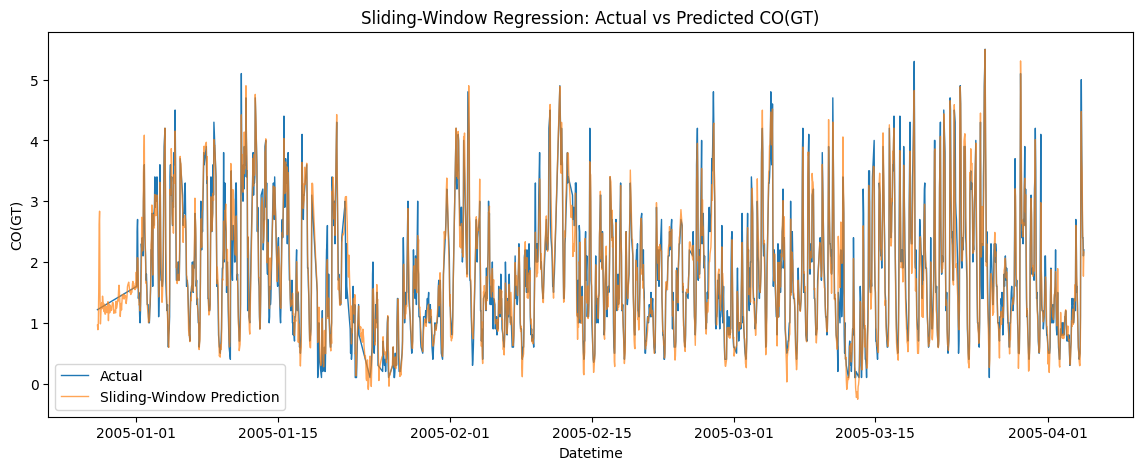

In [26]:
#Step 10


# ===== Sliding-Window (Recursive) Regression =====
# Idea: repeatedly retrain on a fixed-size window to predict the next single step,
# then slide the window forward (to adapt to drift)

window_size = 24 * 7   # 7 days of hourly data = 168 rows (can be changed if needed)

X_full = df[final_features].reset_index(drop=True)
y_full = df['CO(GT)'].reset_index(drop=True)
datetime_full = df.index

# We will do sliding window prediction only over the test period (train period is used as the initial window)
start_idx = split_idx  # split point coming from Step 7

sliding_preds = []
sliding_actuals = []
sliding_dates = []

for i in range(start_idx, len(X_full)):
    # window: the window_size rows before the current point
    window_start = i - window_size
    if window_start < 0:
        window_start = 0

    X_window = X_full.iloc[window_start:i]
    y_window = y_full.iloc[window_start:i]

    # Fit a fresh small model each time (drift-adaptive)
    model = LinearRegression()
    model.fit(X_window, y_window)

    # Predict the next single point
    X_next = X_full.iloc[[i]]
    pred = model.predict(X_next)[0]

    sliding_preds.append(pred)
    sliding_actuals.append(y_full.iloc[i])
    sliding_dates.append(datetime_full[i])

# ===== Evaluation =====
sliding_preds = np.array(sliding_preds)
sliding_actuals = np.array(sliding_actuals)

sliding_rmse = np.sqrt(mean_squared_error(sliding_actuals, sliding_preds))
sliding_mae = mean_absolute_error(sliding_actuals, sliding_preds)
sliding_r2 = r2_score(sliding_actuals, sliding_preds)

print("===== Sliding-Window (Recursive) Regression Results =====")
print(f"Test RMSE: {sliding_rmse:.4f} | Test MAE: {sliding_mae:.4f} | Test R²: {sliding_r2:.4f}")

# ===== Comparison with all models (OLS, Huber, RANSAC, Sliding-Window) =====
comparison_df_full = pd.DataFrame({
    'Model': ['OLS', 'Huber', 'RANSAC', 'Sliding-Window'],
    'Test RMSE': [test_rmse, huber_test_rmse, ransac_test_rmse, sliding_rmse],
    'Test MAE': [test_mae, huber_test_mae, ransac_test_mae, sliding_mae],
    'Test R2': [test_r2, huber_test_r2, ransac_test_r2, sliding_r2]
})

print("\n===== Full Model Comparison Table =====")
print(comparison_df_full)

# ===== Plot: Actual vs Sliding-Window Prediction =====
plt.figure(figsize=(14,5))
plt.plot(sliding_dates, sliding_actuals, label='Actual', linewidth=1)
plt.plot(sliding_dates, sliding_preds, label='Sliding-Window Prediction', linewidth=1, alpha=0.7)
plt.title('Sliding-Window Regression: Actual vs Predicted CO(GT)')
plt.xlabel('Datetime')
plt.ylabel('CO(GT)')
plt.legend()
plt.show()

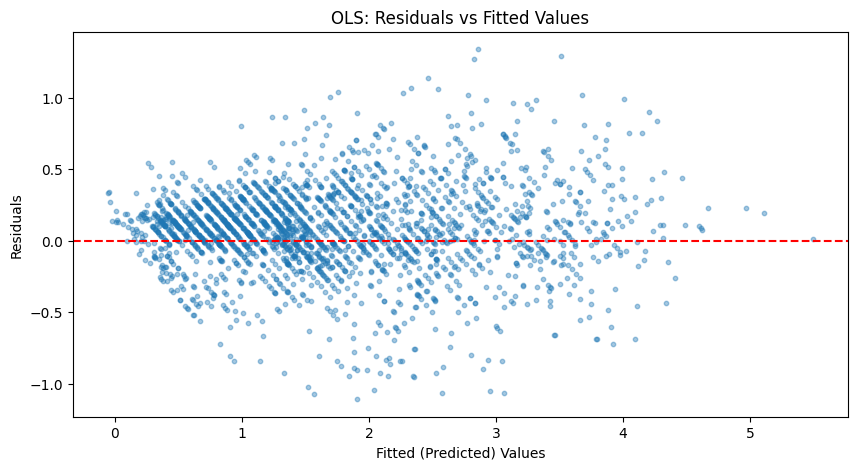

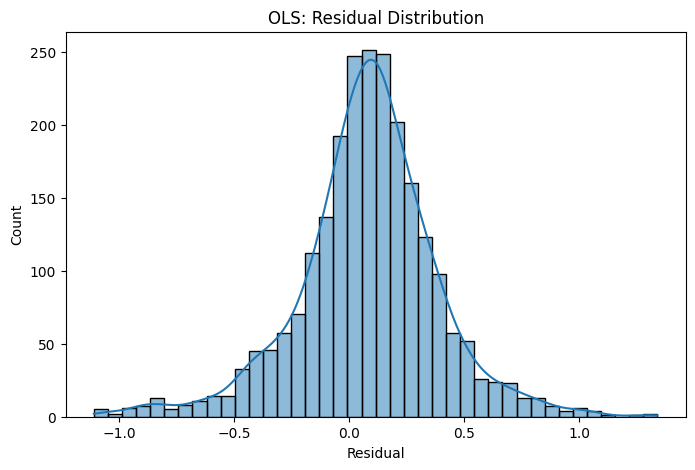

===== Durbin-Watson Statistic (Autocorrelation Check) =====
OLS Residuals   : 0.6458
Huber Residuals : 0.6337
RANSAC Residuals: 0.5529

(Note: A DW value close to 2 means no autocorrelation.
Close to 0 means positive autocorrelation, close to 4 means negative autocorrelation)

===== Paired t-test (Absolute Errors) =====
OLS vs Huber  → t-stat: -15.4291, p-value: 0.0000
OLS vs RANSAC → t-stat: -17.8427, p-value: 0.0000

(Note: p-value < 0.05 means the difference in error between the two models is statistically significant)

OLS vs Sliding-Window → t-stat: 11.0958, p-value: 0.0000


In [27]:
#Step 11


# ===== 1. Residual Calculation =====
residuals_ols = y_test.values - y_test_pred
residuals_huber = y_test.values - y_test_pred_huber
residuals_ransac = y_test.values - y_test_pred_ransac

# ===== 2. Residual Plot (Fitted vs Residual) — for the OLS Model =====
plt.figure(figsize=(10,5))
plt.scatter(y_test_pred, residuals_ols, alpha=0.4, s=10)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('OLS: Residuals vs Fitted Values')
plt.xlabel('Fitted (Predicted) Values')
plt.ylabel('Residuals')
plt.show()

# ===== 3. Residual Distribution (Histogram) =====
plt.figure(figsize=(8,5))
sns.histplot(residuals_ols, bins=40, kde=True)
plt.title('OLS: Residual Distribution')
plt.xlabel('Residual')
plt.show()

# ===== 4. Durbin-Watson Test (Autocorrelation Check) =====
dw_ols = durbin_watson(residuals_ols)
dw_huber = durbin_watson(residuals_huber)
dw_ransac = durbin_watson(residuals_ransac)

print("===== Durbin-Watson Statistic (Autocorrelation Check) =====")
print(f"OLS Residuals   : {dw_ols:.4f}")
print(f"Huber Residuals : {dw_huber:.4f}")
print(f"RANSAC Residuals: {dw_ransac:.4f}")
print("\n(Note: A DW value close to 2 means no autocorrelation.")
print("Close to 0 means positive autocorrelation, close to 4 means negative autocorrelation)")

# ===== 5. Paired t-test — comparing Absolute Error of OLS vs Huber =====
abs_err_ols = np.abs(residuals_ols)
abs_err_huber = np.abs(residuals_huber)
abs_err_ransac = np.abs(residuals_ransac)

t_stat_oh, p_val_oh = ttest_rel(abs_err_ols, abs_err_huber)
t_stat_or, p_val_or = ttest_rel(abs_err_ols, abs_err_ransac)

print("\n===== Paired t-test (Absolute Errors) =====")
print(f"OLS vs Huber  → t-stat: {t_stat_oh:.4f}, p-value: {p_val_oh:.4f}")
print(f"OLS vs RANSAC → t-stat: {t_stat_or:.4f}, p-value: {p_val_or:.4f}")
print("\n(Note: p-value < 0.05 means the difference in error between the two models is statistically significant)")

# ===== 6. Also compare against the Sliding-Window model (if same length) =====
# Sliding window predictions need to be matched with the last portion of the test set
n_sliding = len(sliding_actuals)
abs_err_sliding = np.abs(sliding_actuals - sliding_preds)
abs_err_ols_matched = abs_err_ols[-n_sliding:]  # matching OLS errors to the same length

t_stat_os, p_val_os = ttest_rel(abs_err_ols_matched, abs_err_sliding)
print(f"\nOLS vs Sliding-Window → t-stat: {t_stat_os:.4f}, p-value: {p_val_os:.4f}")

In [28]:

# ----- Random Forest Tuning -----
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)

# ----- XGBoost Tuning -----
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}
xgb_grid = GridSearchCV(XGBRegressor(random_state=42), param_grid_xgb, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)
best_xgb = xgb_grid.best_estimator_
print("Best XGB params:", xgb_grid.best_params_)

Best RF params: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}
Best XGB params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [29]:
#Step 12


# ===== 1. Mean Baseline (simplest reference) =====
mean_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())

mean_rmse = np.sqrt(mean_squared_error(y_test, mean_pred))
mean_mae = mean_absolute_error(y_test, mean_pred)
mean_r2 = r2_score(y_test, mean_pred)

print("===== Mean Baseline Results =====")
print(f"Test RMSE: {mean_rmse:.4f} | Test MAE: {mean_mae:.4f} | Test R²: {mean_r2:.4f}")

# ===== 2. Decision Tree Regressor =====
dt_model = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)

y_test_pred_dt = dt_model.predict(X_test)

dt_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_dt))
dt_mae = mean_absolute_error(y_test, y_test_pred_dt)
dt_r2 = r2_score(y_test, y_test_pred_dt)

print("\n===== Decision Tree Regressor Results =====")
print(f"Test RMSE: {dt_rmse:.4f} | Test MAE: {dt_mae:.4f} | Test R²: {dt_r2:.4f}")

# ===== 3. SVR (Support Vector Regressor) =====

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr_model = SVR(kernel='rbf', C=10, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)

y_test_pred_svr = svr_model.predict(X_test_scaled)

svr_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_svr))
svr_mae = mean_absolute_error(y_test, y_test_pred_svr)
svr_r2 = r2_score(y_test, y_test_pred_svr)

print("\n===== SVR Results =====")
print(f"Test RMSE: {svr_rmse:.4f} | Test MAE: {svr_mae:.4f} | Test R²: {svr_r2:.4f}")

# ===== 4. Full Comparison Table (all models together) =====
final_comparison_df = pd.DataFrame({
    'Model': ['Mean Baseline', 'OLS', 'Huber', 'RANSAC', 'Sliding-Window', 'Decision Tree', 'SVR'],
    'Test RMSE': [mean_rmse, test_rmse, huber_test_rmse, ransac_test_rmse, sliding_rmse, dt_rmse, svr_rmse],
    'Test MAE': [mean_mae, test_mae, huber_test_mae, ransac_test_mae, sliding_mae, dt_mae, svr_mae],
    'Test R2': [mean_r2, test_r2, huber_test_r2, ransac_test_r2, sliding_r2, dt_r2, svr_r2]
})

final_comparison_df = final_comparison_df.sort_values('Test RMSE').reset_index(drop=True)

print("\n===== FINAL MODEL COMPARISON TABLE =====")
print(final_comparison_df)

===== Mean Baseline Results =====
Test RMSE: 1.0826 | Test MAE: 0.9183 | Test R²: -0.0753

===== Decision Tree Regressor Results =====
Test RMSE: 0.3801 | Test MAE: 0.2704 | Test R²: 0.8674

===== SVR Results =====
Test RMSE: 0.9948 | Test MAE: 0.8606 | Test R²: 0.0921

===== FINAL MODEL COMPARISON TABLE =====
            Model  Test RMSE  Test MAE   Test R2
0  Sliding-Window   0.262693  0.187853  0.936694
1             OLS   0.315221  0.235757  0.908845
2           Huber   0.321189  0.242584  0.905360
3          RANSAC   0.351324  0.267796  0.886769
4   Decision Tree   0.380118  0.270383  0.867448
5             SVR   0.994834  0.860567  0.092071
6   Mean Baseline   1.082632  0.918314 -0.075257


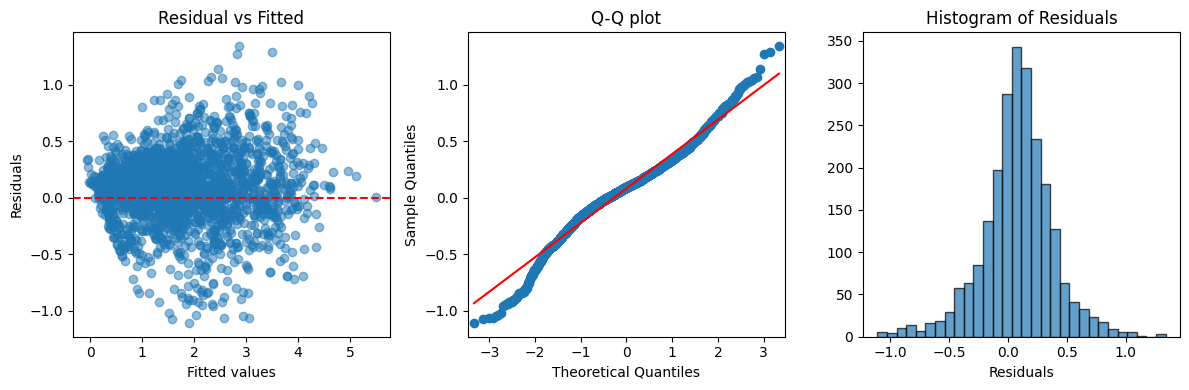

Durbin-Watson statistic: 0.6458
Paired t-test OLS vs Huber: t=-41.1237, p=0.0000
Paired t-test OLS vs RANSAC: t=-23.8844, p=0.0000
Paired t-test OLS vs RF: t=36.2350, p=0.0000
Paired t-test OLS vs XGB: t=76.6725, p=0.0000


In [30]:

# Fit and predict using the OLS model
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)
y_test_pred_ols = ols_model.predict(X_test_scaled)
residuals = y_test - y_test_pred_ols

# Residual vs Fitted plot
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.scatter(y_test_pred_ols, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residual vs Fitted')

# Q-Q plot
plt.subplot(1,3,2)
sm.qqplot(residuals, line='s', ax=plt.gca())
plt.title('Q-Q plot')

# Histogram of Residuals
plt.subplot(1,3,3)
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel('Residuals')
plt.title('Histogram of Residuals')
plt.tight_layout()
plt.show()

# Durbin-Watson test
dw = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw:.4f}")

# Paired t-tests between OLS and other models (using prediction errors)
# The prediction variables for the other models must be defined beforehand:
# y_test_pred_huber, y_test_pred_ransac, y_test_pred_rf, y_test_pred_xgb

models_pred = {
    'Huber': y_test_pred_huber,
    'RANSAC': y_test_pred_ransac,
    'RF': y_test_pred_rf,
    'XGB': y_test_pred_xgb
}

# OLS error
errors_ols = y_test - y_test_pred_ols

for name, pred in models_pred.items():
    errors_other = y_test - pred
    # Paired t-test between the two error vectors
    t_stat, p_val = ttest_rel(errors_ols, errors_other)
    print(f"Paired t-test OLS vs {name}: t={t_stat:.4f}, p={p_val:.4f}")

FINAL RESULTS TABLE
         Model  Test RMSE  Test MAE   Test R2
Sliding-Window   0.262693  0.187853  0.936694
           OLS   0.315221  0.235757  0.908845
         Huber   0.321189  0.242584  0.905360
        RANSAC   0.351324  0.267796  0.886769
 Decision Tree   0.380118  0.270383  0.867448
           SVR   0.994834  0.860567  0.092071
 Mean Baseline   1.082632  0.918314 -0.075257

Best Model (based on lowest RMSE): Sliding-Window
RMSE: 0.2627 | MAE: 0.1879 | R²: 0.9367


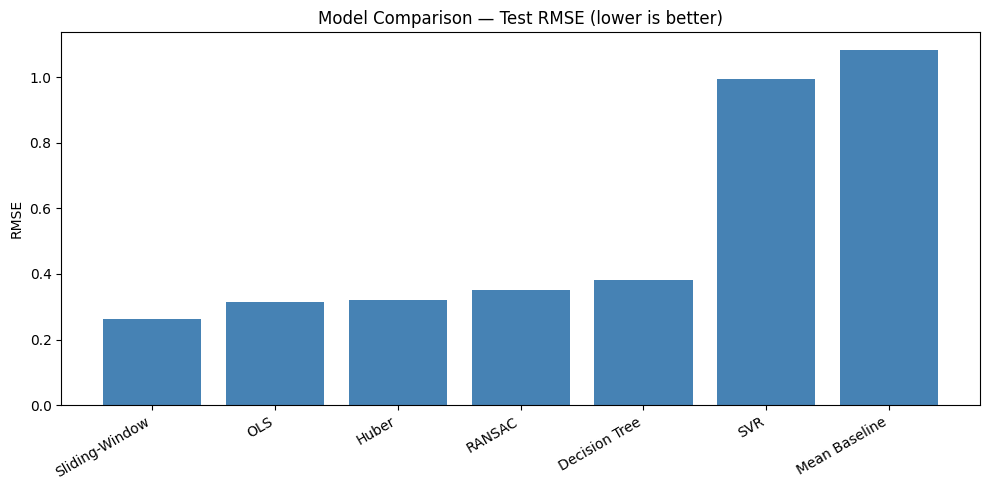

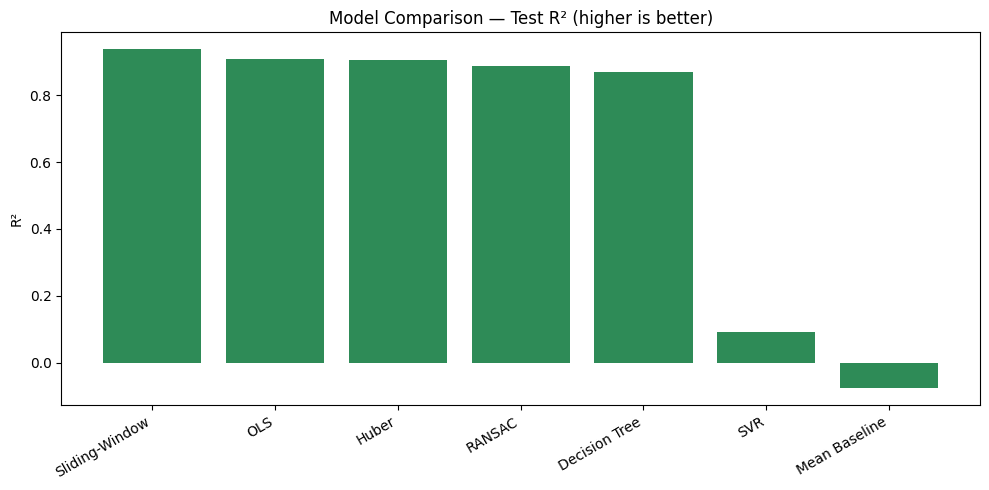


===== Statistical Significance Summary =====
           Comparison      p-value  Significant (p<0.05)
         OLS vs Huber 3.198911e-51                  True
        OLS vs RANSAC 7.314098e-67                  True
OLS vs Sliding-Window 6.455927e-28                  True

CSV files saved: final_model_comparison.csv, significance_summary.csv


In [31]:
#Step 13


# 1. Final Comparison Table (already built in Step 12)
print("FINAL RESULTS TABLE")
print(final_comparison_df.to_string(index=False))

# 2. Identify the best model
best_model_row = final_comparison_df.loc[final_comparison_df['Test RMSE'].idxmin()]
print(f"\nBest Model (based on lowest RMSE): {best_model_row['Model']}")
print(f"RMSE: {best_model_row['Test RMSE']:.4f} | MAE: {best_model_row['Test MAE']:.4f} | R²: {best_model_row['Test R2']:.4f}")

# 3. Bar Chart — RMSE Comparison (all models)
plt.figure(figsize=(10,5))
plt.bar(final_comparison_df['Model'], final_comparison_df['Test RMSE'], color='steelblue')
plt.title('Model Comparison — Test RMSE (lower is better)')
plt.ylabel('RMSE')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# 4. Bar Chart — R² Comparison (all models)
plt.figure(figsize=(10,5))
plt.bar(final_comparison_df['Model'], final_comparison_df['Test R2'], color='seagreen')
plt.title('Model Comparison — Test R² (higher is better)')
plt.ylabel('R²')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# ===== 5. Statistical Significance Summary (p-values from Step 11) =====
significance_summary = pd.DataFrame({
    'Comparison': ['OLS vs Huber', 'OLS vs RANSAC', 'OLS vs Sliding-Window'],
    'p-value': [p_val_oh, p_val_or, p_val_os],
    'Significant (p<0.05)': [p_val_oh < 0.05, p_val_or < 0.05, p_val_os < 0.05]
})
print("\n===== Statistical Significance Summary =====")
print(significance_summary.to_string(index=False))

# ===== 6. Save final results as CSV (for use in report/GitHub) =====
final_comparison_df.to_csv('final_model_comparison.csv', index=False)
significance_summary.to_csv('significance_summary.csv', index=False)
print("\nCSV files saved: final_model_comparison.csv, significance_summary.csv")

In [32]:
# ===== Expected vs Actual Results (for report Discussion section) =====
print("===== Expected vs Actual Performance =====")
print("Proposal expected R² range: 0.50 - 0.80 (moderate predictive power)")
print(f"Best achieved Test R²: {best_model_row['Test R2']:.4f} ({best_model_row['Model']})")

if best_model_row['Test R2'] > 0.80:
    print("\nObservation: Actual performance exceeded the expected range,")
    print("suggesting the selected sensor features (via LASSO/VIF) captured")
    print("strong linear relationships with CO(GT) concentration.")
elif 0.50 <= best_model_row['Test R2'] <= 0.80:
    print("\nObservation: Actual performance falls within the expected range,")
    print("consistent with the anticipated moderate predictive power.")
else:
    print("\nObservation: Actual performance fell below the expected range,")
    print("indicating stronger nonlinearity or drift effects than anticipated.")

===== Expected vs Actual Performance =====
Proposal expected R² range: 0.50 - 0.80 (moderate predictive power)
Best achieved Test R²: 0.9367 (Sliding-Window)

Observation: Actual performance exceeded the expected range,
suggesting the selected sensor features (via LASSO/VIF) captured
strong linear relationships with CO(GT) concentration.


In [33]:

# Ensure X_train_scaled is a DataFrame (if not, convert it)
if not isinstance(X_train_scaled, pd.DataFrame):
    # if it's a numpy array, convert using feature names from X_train
    feature_names = X_train.columns  # X_train is original unscaled DataFrame
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)

# Also ensure y_train is a Series (it should be)
if not isinstance(y_train, pd.Series):
    y_train = pd.Series(y_train)

# Sliding window parameters
window_size = 500
predictions = []
actuals = []

for i in range(window_size, len(X_train_scaled)):
    X_win = X_train_scaled.iloc[i-window_size:i]
    y_win = y_train.iloc[i-window_size:i]
    model = LinearRegression()
    model.fit(X_win, y_win)
    # Predict the next point
    X_next = X_train_scaled.iloc[i:i+1]
    y_next = y_train.iloc[i]
    pred = model.predict(X_next)[0]
    predictions.append(pred)
    actuals.append(y_next)

rmse_sw = np.sqrt(mean_squared_error(actuals, predictions))
mae_sw = mean_absolute_error(actuals, predictions)
print(f"Sliding Window (window={window_size}) -> RMSE: {rmse_sw:.4f}, MAE: {mae_sw:.4f}")

Sliding Window (window=500) -> RMSE: 0.2967, MAE: 0.2166


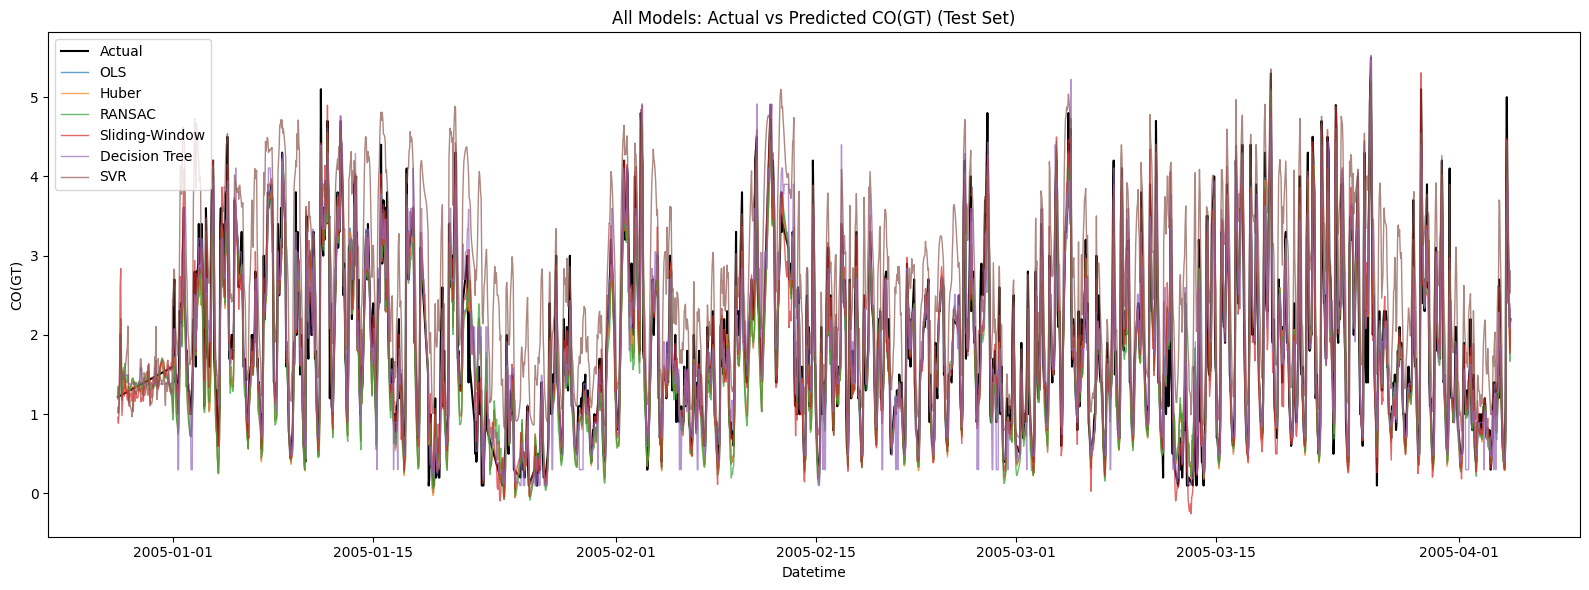

In [34]:
#Step 14
# Combined Actual vs Predicted plot for ALL models on the test set

plt.figure(figsize=(16, 6))
plt.plot(test_df.index, y_test, label='Actual', color='black', linewidth=1.5)
plt.plot(test_df.index, y_test_pred, label='OLS', linewidth=1, alpha=0.7)
plt.plot(test_df.index, y_test_pred_huber, label='Huber', linewidth=1, alpha=0.7)
plt.plot(test_df.index, y_test_pred_ransac, label='RANSAC', linewidth=1, alpha=0.7)
plt.plot(test_df.index, sliding_preds, label='Sliding-Window', linewidth=1, alpha=0.7)
plt.plot(test_df.index, y_test_pred_dt, label='Decision Tree', linewidth=1, alpha=0.7)
plt.plot(test_df.index, y_test_pred_svr, label='SVR', linewidth=1, alpha=0.7)
plt.title('All Models: Actual vs Predicted CO(GT) (Test Set)')
plt.xlabel('Datetime')
plt.ylabel('CO(GT)')
plt.legend()
plt.tight_layout()
plt.show()

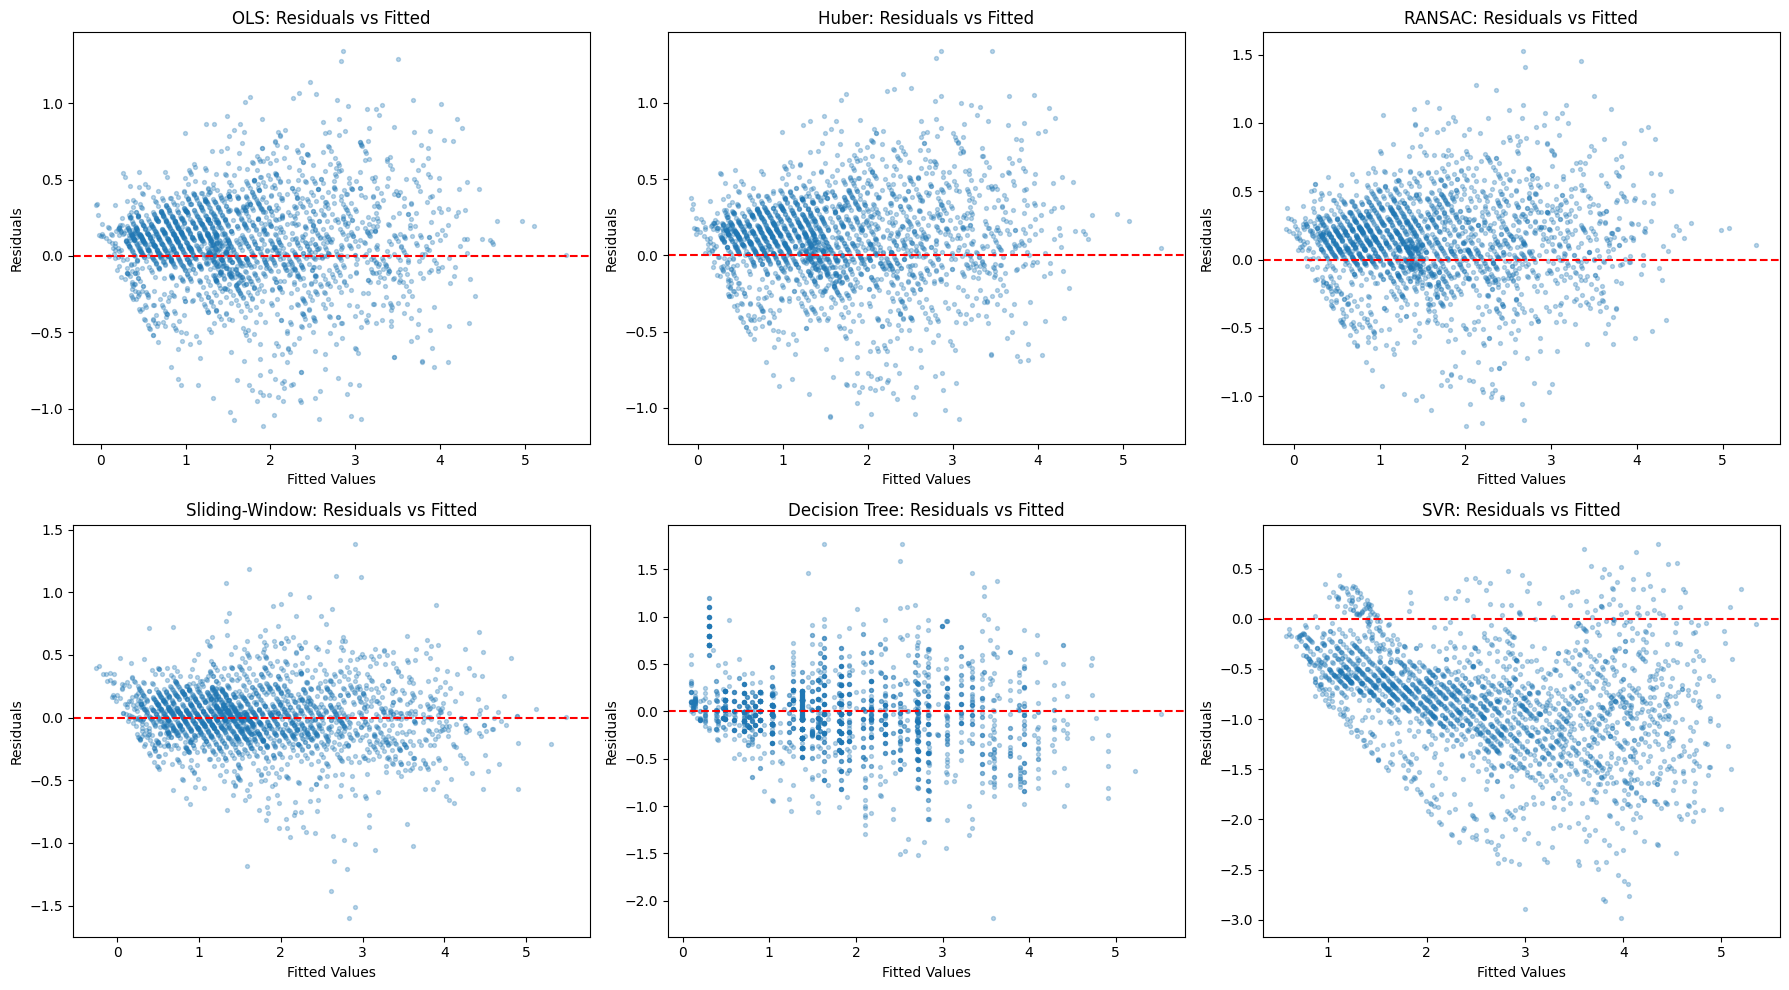

In [35]:
#Step 15
# Residual plots (Fitted vs Residual) for ALL models in one figure

residuals_dt = y_test.values - y_test_pred_dt
residuals_svr = y_test.values - y_test_pred_svr
residuals_sliding = sliding_actuals - sliding_preds

models_residuals = {
    'OLS': (y_test_pred, residuals_ols),
    'Huber': (y_test_pred_huber, residuals_huber),
    'RANSAC': (y_test_pred_ransac, residuals_ransac),
    'Sliding-Window': (sliding_preds, residuals_sliding),
    'Decision Tree': (y_test_pred_dt, residuals_dt),
    'SVR': (y_test_pred_svr, residuals_svr),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, (fitted, resid)) in enumerate(models_residuals.items()):
    axes[i].scatter(fitted, resid, alpha=0.3, s=8)
    axes[i].axhline(y=0, color='red', linestyle='--')
    axes[i].set_title(f'{name}: Residuals vs Fitted')
    axes[i].set_xlabel('Fitted Values')
    axes[i].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

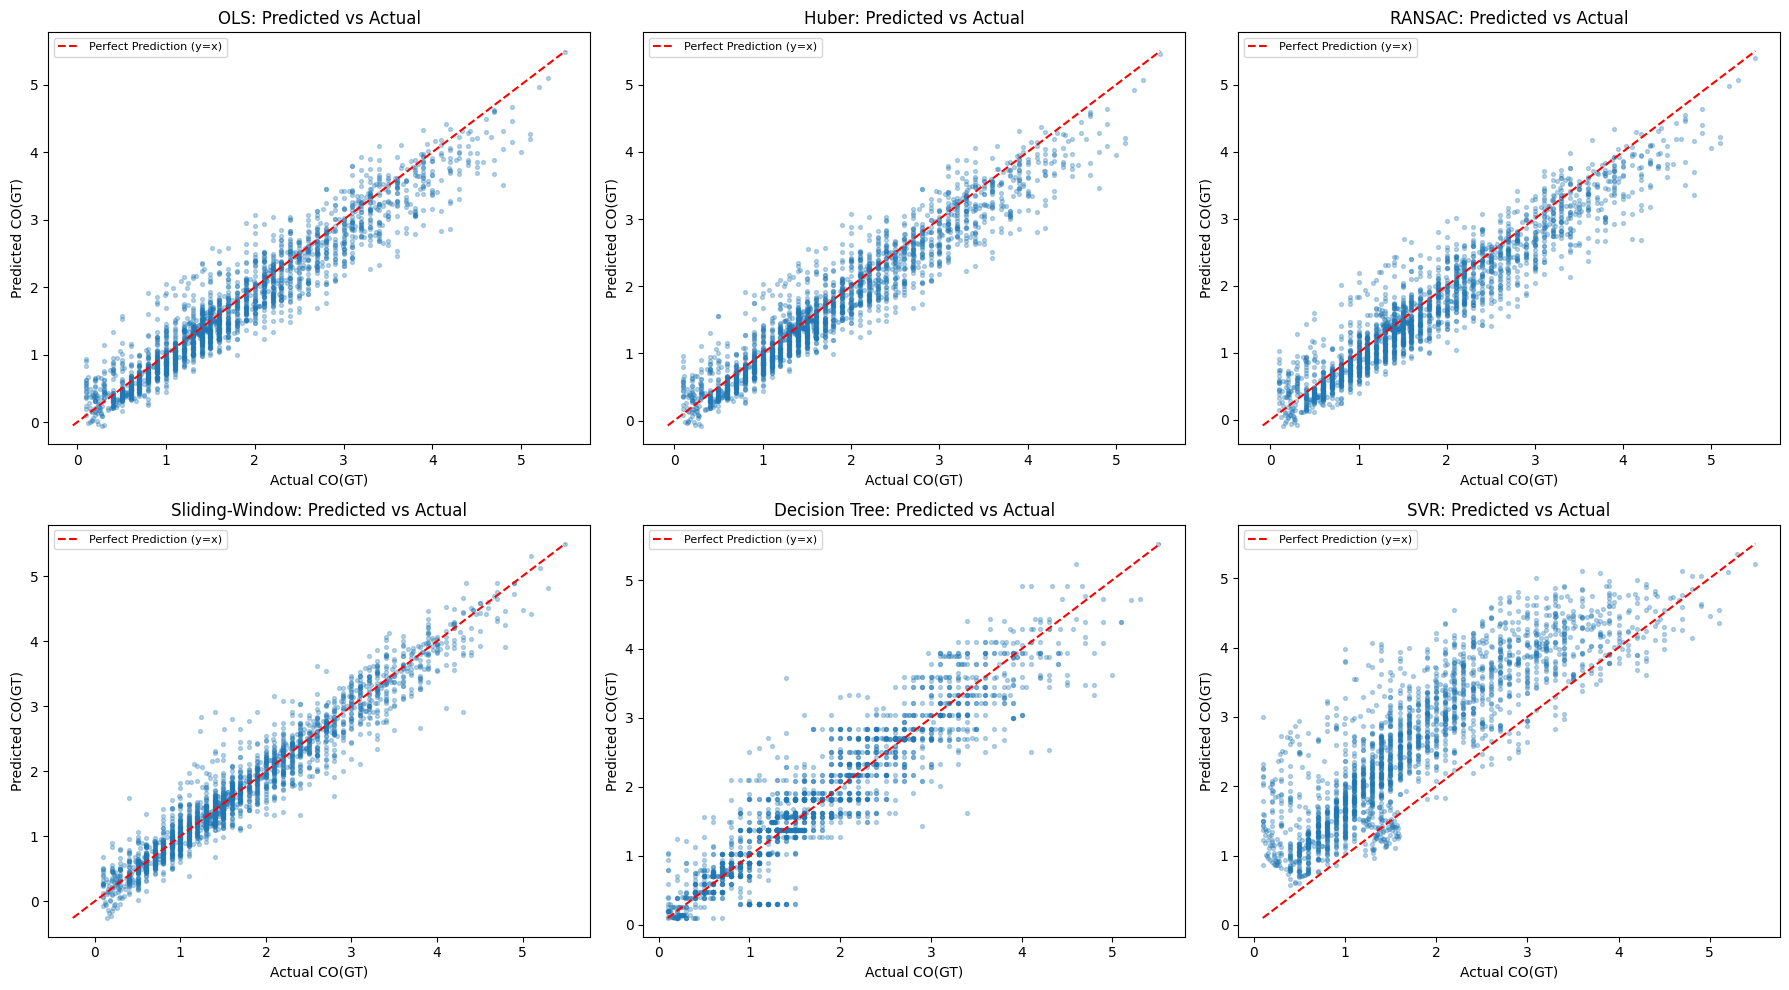

In [36]:
#Step 16
# Predicted vs Actual scatter plots (with y=x reference line) for ALL models

models_preds = {
    'OLS': y_test_pred,
    'Huber': y_test_pred_huber,
    'RANSAC': y_test_pred_ransac,
    'Sliding-Window': sliding_preds,
    'Decision Tree': y_test_pred_dt,
    'SVR': y_test_pred_svr,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, preds) in enumerate(models_preds.items()):
    actual_vals = sliding_actuals if name == 'Sliding-Window' else y_test.values
    axes[i].scatter(actual_vals, preds, alpha=0.3, s=8)
    min_val = min(actual_vals.min(), preds.min())
    max_val = max(actual_vals.max(), preds.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction (y=x)')
    axes[i].set_title(f'{name}: Predicted vs Actual')
    axes[i].set_xlabel('Actual CO(GT)')
    axes[i].set_ylabel('Predicted CO(GT)')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

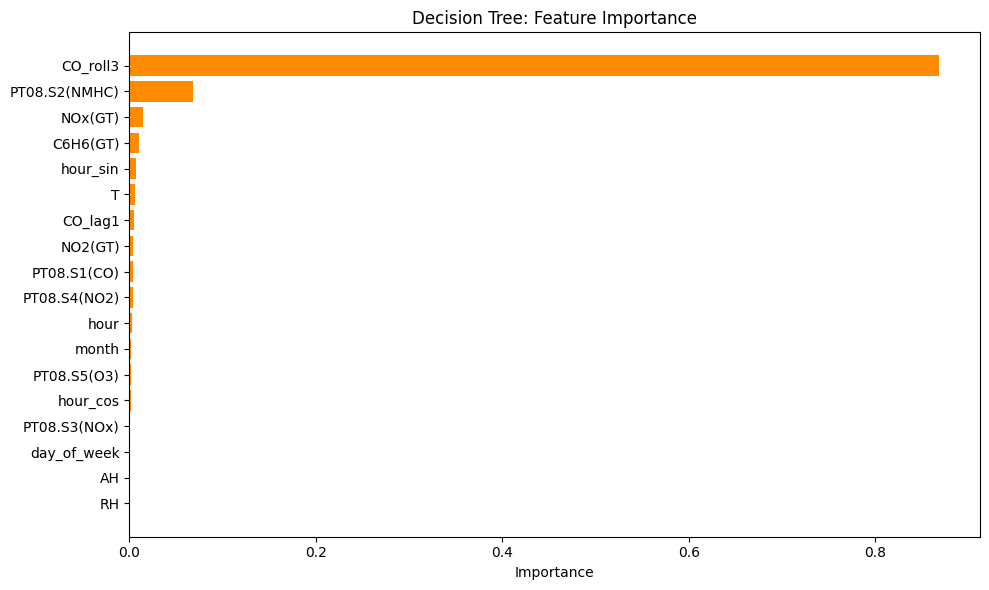

      Feature  Importance
     CO_roll3    0.869032
PT08.S2(NMHC)    0.067685
      NOx(GT)    0.015032
     C6H6(GT)    0.010247
     hour_sin    0.006678
            T    0.005453
      CO_lag1    0.004697
      NO2(GT)    0.003954
  PT08.S1(CO)    0.003702
 PT08.S4(NO2)    0.003267
         hour    0.002885
        month    0.001706
  PT08.S5(O3)    0.001481
     hour_cos    0.001381
 PT08.S3(NOx)    0.000962
  day_of_week    0.000763
           AH    0.000601
           RH    0.000475


In [37]:
#Step 17
# Feature importance from the Decision Tree Regressor

importance_df = pd.DataFrame({
    'Feature': final_features,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='darkorange')
plt.title('Decision Tree: Feature Importance')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))